# Text Analysis :

**Overview**

This project will implement two topic extraction modeling pipelines:
- Pipeline_1: CountVectorizer + Latent Semantic Analysis (`TruncatedSVD`)
- Pipeline_2: TfidfVectorizer + Latent Dirichlet Allocation (`LDA`)

## Pipeline_1: Latent Semantic Analysis (LSA) by using Bag-of-Words (BoW)

This pipeline will implement the first topic extraction model. 
This model will learn by feeding it with a Municipal Complaint Texts as a training dataset.

### Step 1: - Import Libraries:
All libraries needed throughout this pipeline will be imported and listed in one code block.
Every library's dependency for this notebook is visible in one place from the start in Block 1.

In [1]:
# Block 1

import pandas as pd
# Loads the pandas library into memory and gives it the short
# nickname 'pd' for easier reference in the code lines. 
# 'Pandas' is a build and manage structured data tables in Python ('DataFrames') and provides tools for data manipulation, analysis, and visualization.
# Used here to load the municipal complaint dataset CSV file and select the relevant column 'issue_description' for the topic modeling analysis.

import re
# 're' is a built-in Python library, provides support for working with 'regular-expressions', 
# This will help to clean the texts by removing punctuation, special characters, 
# and other unwanted elements from the municipal complaint texts.
# Since punctuation is not a meaningful unit for 'bag-of-words' counting in this pipeline, we will remove it from the texts.

import nltk
from nltk.tokenize import word_tokenize
# 'nltk' is a popular library for natural language processing (NLP) tasks in Python.
# Here, will split each cleaned complaint into individual words (tokens), and then the 'CountVectorizer' can count word occurrences.
# 'word_tokenize' method from the 'nltk.tokenize' module used for this purpose.
# It will split the text into individual words and punctuation marks based on specific linguistic rules.

from IPython.display import display, Markdown
from IPython.display import display, HTML
# These two libraries are imported just for displaying results' purposes. 

from nltk.corpus import stopwords
# 'stopwords' is a module from the 'nltk.corpus' library. 
# That provides a list of common English words (stopwords), e.g., ("the", "is") that are typically removed from text during preprocessing.
# So, they do not dominate the word counts used to build the 'Bag-of-Words' (BoW) document-term matrix in this pipeline.

from nltk.stem import WordNetLemmatizer
# 'WordNetLemmatizer' is a class from the 'nltk.stem' module.
# It reduces words to their base form (e.g., "running" --> "run", "better" --> "good")
# to reduce the vocabulary size and improve the topic model's performance.

from sklearn.feature_extraction.text import CountVectorizer
# 'CountVectorizer' is a class from the sklearn.feature_extraction.text module.
# Builds the Bag-of-words (BoW) document-term matrix for this pipeline, 
# Counting how many times each word appears in each complaint text.


from sklearn.decomposition import TruncatedSVD
# 'TruncatedSVD' is a class from the 'sklearn.decomposition' module.
# Performs Latent Semantic Analysis (LSA) on the 'Bag-of-Words' (BoW) document-term matrix,
# reducing it to a smaller set of latent topics for this pipeline.



from gensim.corpora import Dictionary 
# 'Dictionary' is a class from the 'gensim.corpora' module. It converts the tokenized complaints into 
# a dictionary format, which is a mapping of unique words to their integer IDs.
#  It is required by gensim's CoherenceModel to compute the coherence score for the topics generated by the LSA model.

from gensim.models import CoherenceModel
# 'CoherenceModel' is a class from the 'gensim.models' module. It computes the coherence score for the candidate numbers of topics (k).
# So, the optimal (k) for this 'LSA' pipeline is chosen based on evidence, not just personally chosen. 
# The coherence score measures the semantic similarity between the words in each topic.

import matplotlib.pyplot as plt
# 'matplotlib.pyplot' is a module from the 'matplotlib' library, which is used for creating visualizations in Python.
# Here, it will be used to plot the coherence scores for different numbers of topics in the 'LSA' model,
#  helping to determine the optimal number of topics for this pipeline.
# We can also use it to visually identify the optimal number of topics as a plot graph,
#  where the x-axis represents the number of topics and the y-axis represents the coherence score.


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
# Download 'NLTK' resources needed for tokenization and stopword removal.
#  The 'punkt' resource is used for tokenizing text into sentences and words.
# 'punkt_tab' is used for tokenizing text that contains tab characters.
#  while 'stopwords' provides a list of common words that are typically removed from text during preprocessing.

nltk.download('wordnet')
# Download WordNet lemmatizer resource.
# 'wordnet' is a lexical database of English words that provides a list of word stems (base forms) for lemmatization.

nltk.download('omw-1.4')
# Download Open Multilingual Wordnet (OMW) resource.
# 'omw-1.4' is a multilingual lexical database of word stems (base forms) for lemmatization.
# It provides a list of word stems for words in different languages, including English.

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\moaaz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\moaaz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moaaz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\moaaz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\moaaz\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Step 2: Load the Dataset file and select the Relevant Column to work on it.

The municipal complaints dataset is loaded from the CSV file using 'pd.read_csv()' function from the pandas library.

The relevant column 'issue_description' is selected from the loaded dataset for topic modeling analysis using the method
`.loc[:, 'issue_description']`.

All other columns are ignored, as they are not needed for this analysis.
The selected column is stored in a new variable called 'complaints' for further processing in the pipeline.

 Some rows of the selected column could repeat the same complaint text; if these duplicates are not removed, the topic model would 
 treat each repeated complaint as a separate occurance, making that issue truly is, and will distort the final ranking of topics. 
 
 For this reason, duplicate rows in ('issue_description') are removed immediately after loading, using the method 'drop_duplicates()' from pandas, before any further processing takes place. 
 

In [10]:
# Block 2 

df = pd.read_csv('municipal_complaints_training_dataset.csv')
# 'pd.read_csv('the name of the dataset file')' this method reads the dataset file from disk and loads it into 
# a pandas DataFrame called 'df', which now holds 1100 rows and 26 columns of the original dataset.

complaints = df.loc[:, 'issue_description']
# 'df.loc[:, 'issue_description']' will select only the 'issue_description column from 'df' dataset.
# The resulting column will be stored in a new variable 'complaints', separated from the original dataset.

complaints = complaints.drop_duplicates()
# 'complaints.drop_duplicates()' will read the rows in 'complaints', loop inside it, and match if there are duplicate rows.
# If matches are found, it will remove the duplicated row, then return to 'complaints' new rows without duplicated text rows.

complaints = complaints.reset_index(drop = True)
# After dropping duplicates, the row orders have some gaps due to removing repeated rows, 
# 'complaints.reset_index(drop = True)' will rebuild the correct order of the rows, so later indexing works correctly.

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown(f"<b>The Number of Complaints after dropping duplicates:</b> {complaints.shape[0]}"))

display(Markdown("<b>First 5 rows of the complaints:</b>"))

# Here we will check how many rows were dropped or were duplicated in the original dataset.

display(complaints.head().to_frame())
# Here we will display the first 5 rows of the 'complaints' as a visual check to verify that
#  the text needed for further processing looks correct and exactly as we need before moving further.


<h3>The output of this block is:</h3>

<b>The Number of Complaints after dropping duplicates:</b> 447

<b>First 5 rows of the complaints:</b>

,issue_description
0,Unauthorized late-night party with amplified s...
1,Deep pothole near the bus stop making it dange...
2,Construction crew is starting their work at 5 ...
3,URGENT: A significant water leak near the scho...
4,Can someone please fix a small pothole that is...



### Step 3 : Clean the Complaint Text

Before the complaints can be converted into a Bag-of-Words (term-document matrix), the raw text must be cleaned,
since unprocessed text contains inconsistencies (different letter casing, punctuation, common words with no real topical meaning)
that would weaken the quality of the topics extracted later.

Following the project plan, four cleaning steps are applied to each complaint text in the 'complaints' variable.

1. **Lowercasing**: converts all text to lowercase, so that words like "Water" and "water" are treated as the same word instead of 
two different words. because the letters 'W' and 'w' are different in the ASCII table.

2. **Punctuation Removal**: removes punctuation marks and special characters, such as (@, $, euro symbol, etc.), since they are not meaningful chracters, that they could not change or affect the topic modeling analysis process.

3. **Tokenization**: splits each cleaned complaint text into
individual words/tokens using the 'word-tokenization' method from the nltk library.

4. **Stopword Removal**: removes common English words (e.g., "the", "is", "and", "in", etc.)  that carry trivial meaning and would otherwise dominate the Bag-of-Words (BoW) frequency counting process. However, words like "no", "not", "none" should be kept, since removing them could change the meaning of complaint texts.

5. **Lemmatization**: reduces words to their base form (e.g., "running" -> "run", "better" -> "good") to reduce the vocabulary size and improve the topic model's performance.

The cleaned tokens for each complaint text are stored for use in the next step, where they will be converted into a Bag-of-Words (BoW)/document-term matrix.

In [7]:
# Block 3

def clean_complaint_text(text):
    
    text = text.lower()
    # 1. Lowercasing
    # convert all text to lowercase.
    
    text = text.replace('-', ' ')
    # 2. convert hyphens to spaces, so hephened words (e.g., "late-night") become 
    # two separate meaningful words/tokens.

    text = re.sub(r'[^a-z\s]', '', text)
    # 3. remove remaining punctuation and special characters, keeping only letters and spaces. 
    # Since they are not meaningful chracters that they couod change or affect the topic modeling analysis process.

    tokens = word_tokenize(text)
    # 4. Split the cleaned text into individual words/tokens using 'word-tokenize' method from nltk library.

    stop_words = set(stopwords.words('english'))
    retained_words = {'no', 'not', 'non'}
    stop_words = stop_words - retained_words
    # 5. Define the stopwords list, keeping 'no', 'not', 'non' words, since they carry meaning in the complaint texts.

    tokens = [t for t in tokens if t not in stop_words]
    # 6. Remove the stopwords from the tokens list.

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    # 7. Lemmatize the tokens to their base form (e.g., "running" into "run")

    return tokens
    # 8. Return the cleaned tokens to the function. 

cleaned_tokens = complaints.apply(clean_complaint_text)
# 'complaints.apply(clean_complaint_text)' will apply the 'clean_complaint_text' function 
#to each complaint text in the 'complaints' variable.
# The function will return a list of cleaned tokens for each complaint text.
# The resulting list of cleaned tokens will be stored in a new variable called 'cleaned_tokens'.
cleaned_text = cleaned_tokens.apply(lambda tokens: ' '. join(tokens))
# 'cleaned_tokens.apply(lambda tokens: ''. join(tokens))' will apply the 'lambda' function
# to each list of cleaned tokens in the 'cleaned_tokens' variable.
# The 'lambda' function will join the list of cleaned tokens into a single string for each complaint text.
# The resulting string list will be stored in a new CSV file so we do not need 
# to rebuild this process again in pipeline_2.

preprocessed_complaints = pd.DataFrame({'cleaned_text': cleaned_text})
# 'pd.DataFrame({'cleaned_text': cleaned_text})' will create a new DataFrame called 'preprocessed_complaints'
# with a single column called 'cleaned_text' that contains the cleaned text for each complaint text.
# The resulting DataFrame will be stored in a new CSV file.

preprocessed_complaints.to_csv('preprocessed_complaints.csv', index=False)
# 'preprocessed_complaints.to_csv('the name of the new csv file')' will save the 'preprocessed_complaints' DataFrame to a new CSV file.
# The index is set to False, so the index column is not included in the new CSV file.
# The new CSV file will be saved in the current working directory.


display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown(" **First 5 rows of cleaned tokens**"))
display(cleaned_tokens.head().to_frame(name="cleaned_tokens"))

# Here we will display the first 5 rows of the 'cleaned_tokens' as a visual check to verify that
# the cleaned tokens look correct and exactly as we need before moving further.

display(Markdown(" **First 5 rows of preprocessed complaints**"))
display(preprocessed_complaints.head())
# Here we will display the first 5 rows of the 'preprocessed_complaints' as a visual check to verify that
# the preprocessed complaints look correct and exactly as we need before moving further.




<h3>The output of this block is:</h3>

 **First 5 rows of cleaned tokens**

,cleaned_tokens
0,"[unauthorized, late, night, party, amplified, ..."
1,"[deep, pothole, near, bus, stop, making, dange..."
2,"[construction, crew, starting, work, way, loud..."
3,"[urgent, significant, water, leak, near, schoo..."
4,"[someone, please, fix, small, pothole, getting..."


 **First 5 rows of preprocessed complaints**

,cleaned_text
0,unauthorized late night party amplified sound ...
1,deep pothole near bus stop making dangerous co...
2,construction crew starting work way loud viola...
3,urgent significant water leak near school entr...
4,someone please fix small pothole getting deepe...



### Step 4 : Build the Bag-of-Words (BoW) Document-Term Matrix

With the complaint texts now cleaned and preprocessed, the next step is to convert them into a numeric representation 
'Bag-of-Words' (BoW) Document-Term Matrix.

With this matrix, machine learning models can process these texts as a numerical representation.
This is done using the 'CountVectorizer' class from the 'sklearn' library, which builds the document-term matrix:

Each row represents one complaint text, each column represents one unique word/term belongs to the vocabulary,
and each cell represents the number of times this single word appeared in the complaint text.
Then, this matrix is the required input for the next step, which we will discuss in the next block.


In [8]:
# Block 4

vectorizer = CountVectorizer() 
# Initialize the 'CountVectorizer()' which is a class from the sklearn.feature_extraction.text module.

bow_matrix = vectorizer.fit_transform(cleaned_text)
# 'vectorizer.fit_transform(cleaned_text)' will fit the 'CountVectorizer' to the 'cleaned_text'
# and return the BoW matrix 'bow_matrix'.

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown(
    f"**Shape of the Bag-of-Words matrix (documents, vocabulary size): {bow_matrix.shape}**"))
# Here we will check the shape of the Bag-of-Words matrix, 
# which is the number of documents (rows) and the vocabulary size (columns).

display(Markdown(
    f"**Number of unique terms/words in the vocabulary: "
    f"{len(vectorizer.get_feature_names_out())}**"))
# Here we will check the number of unique terms/words in the vocabulary.

display(Markdown(
    f"**Example of vocabulary terms/words: "
    f"{vectorizer.get_feature_names_out()[:10]}**"))
# Here we will display the first 10 terms/words in the vocabulary.

<h3>The output of this block is:</h3>

**Shape of the Bag-of-Words matrix (documents, vocabulary size): (447, 747)**

**Number of unique terms/words in the vocabulary: 747**

**Example of vocabulary terms/words: ['abandoned' 'access' 'accident' 'accumulating' 'across' 'address'
 'adjacent' 'affect' 'affecting' 'afraid']**

### Step 5 : Apply Latent Semantic Analysis (LSA)

With the Bag-of-Words document-term matrix built, Latent Semantic Analysis (LSA) is now applied to reduce
this high-dimensional, sparse matrix into a smaller set of latent topics. This is done using `TruncatedSVD`
from `sklearn.decomposition`, which performs a dimensionality reduction technique called Singular Value
Decomposition, adapted specifically for sparse matrices like the one produced by `CountVectorizer`.

`TruncatedSVD` requires the number of latent topics to extract (`n_components`) to be specified in advance.
At this stage, a placeholder value of 5 is used only to demonstrate how the method works and what its
output looks like. The actual, optimal number of topics will be determined in the next step, using topic
coherence scores, rather than being chosen arbitrarily here.

After fitting the model, each complaint is represented as a vector of 5 values instead of the original
`747 word counts`. The model also reports `explained_variance_ratio_`, which shows how much of the
original matrix's variation each extracted topic accounts for.
Summed across all 5 topics, this placeholder model explains only about 14.2% of the total variance in the data, which is expected for
an arbitrarily chosen, unoptimized number of topics.
This low value is a further reason why the number of topics should not be chosen arbitrarily,
and will motivate the coherence-based search for the optimal k in the next step.

In [10]:
# Block 5

lsa_model = TruncatedSVD(n_components=5, algorithm='randomized', n_iter=10, random_state=42)
lsa_matrix = lsa_model.fit_transform(bow_matrix)
# TruncatedSVD requires the number of topics (n_components) to be set in advance.
# Here, a placeholder value (5) is used only to demonstrate the method, since the actual
# optimal number of topics will be determined in the next step using coherence scores.

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown(f"**Shape of the LSA-reduced matrix (documents, topics): {lsa_matrix.shape}**"))
# 'lsa_matrix.shape' reports (number of complaints, number of topics), showing that each
# complaint is now represented as a vector of 5 values instead of 747 word counts

display(Markdown(
    f"**Explained variance ratio per topic: "
    f"{[f'{x:.4f}' for x in lsa_model.explained_variance_ratio_]}**"
))

display(Markdown(
    f"**Total variance explained by these 5 topics: "
    f"{lsa_model.explained_variance_ratio_.sum():.4f}**"
))
# 'explained_variance_ratio_' shows how much of the original matrix's information each
# extracted topic captures; higher values mean that topic explains more of the variation
# in the data


<h3>The output of this block is:</h3>

**Shape of the LSA-reduced matrix (documents, topics): (447, 5)**

**Explained variance ratio per topic: ['0.0325', '0.0331', '0.0301', '0.0270', '0.0198']**

**Total variance explained by these 5 topics: 0.1424**

### Step 6 : Determine the Optimal Number of Topics (k) Using Coherence Scores

Rather than choosing the number of topics (k) arbitrarily, as was done with the placeholder value in the
previous step, the optimal k is determined here using topic coherence scores, calculated with
`gensim.models.CoherenceModel`, as specified in the project plan.

A coherence score measures how semantically related the top words within each topic are to one another.
A higher coherence score indicates that a topic's top words tend to co-occur meaningfully in the corpus,
suggesting the topic is more interpretable and less likely to be a statistical artifact.

To find the optimal k, `TruncatedSVD` is fit repeatedly across a range of candidate k values. For each
fit, the top words of the resulting topics are extracted and passed to `CoherenceModel`, which returns a
coherence score for that particular k. These scores are compared and plotted to identify which k value
produces the most coherent topics.

The search shows coherence decreasing steadily as k increases, with `k=2` producing the highest coherence
score across the entire tested range. 
This suggests that, for this dataset and this particular combination of Bag-of-Words representation with
Latent Semantic Analysis, the model does not statistically support separating the complaints into many
fine-grained topics. 
This could be an observational limitation of `LSA` deserve to be discussed later in the findings comparison phase:
its components, derived from Singular Value Decomposition, are not always as cleanly interpretable as topics extracted by other methods such as
Latent Dirichlet Allocation, which we will work on in pipeline_2. This result will be an important point of comparison against Pipeline 2,
which uses `LDA` on the same underlying dataset.

<h3>The output of this block is:</h3>

**k=2, coherence=0.7074**

**k=3, coherence=0.5987**

**k=4, coherence=0.6731**

**k=5, coherence=0.6462**

...

**k=7, coherence=0.5718**

**k=8, coherence=0.5321**

**k=9, coherence=0.5622**

**k=10, coherence=0.5525**

**Optimal number of topics (k): 2**

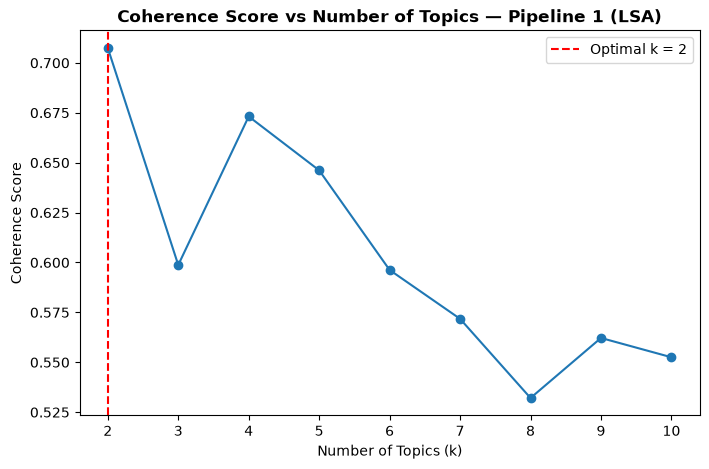

In [11]:
# Block 6

terms = vectorizer.get_feature_names_out()
# retrieve the vocabulary terms learned by CountVectorizer in Block 4, needed here to
# translate each topic's word indices back into actual words


dictionary = Dictionary(cleaned_tokens)
k_values = list(range(2, 11))
# build a gensim Dictionary from the cleaned tokens, mapping each unique word to an integer id;
# this is required by CoherenceModel to compute coherence scores
# define the candidate values of k (number of topics) to test, from 2 to 10 




coherence_scores = []
# this list will store the coherence score obtained for each candidate k

display(Markdown("<h3>The output of this block is:</h3>"))


for k in k_values:
# loop through each candidate k, fit a separate LSA model for it, and evaluate its coherence
    
    lsa_model_k = TruncatedSVD(n_components=k, algorithm='randomized', random_state=42)
    lsa_model_k.fit(bow_matrix)
    # fit TruncatedSVD (LSA) with this specific number of components (topics)
    
    topics_words = []
    for topic in lsa_model_k.components_:
        top_indices = topic.argsort()[::-1][:10]
        top_words = [terms[i] for i in top_indices]
        topics_words.append(top_words)
        # for each topic (component) produced by this model, extract its top 10 most important words;
        # 'lsa_model_k.components_' holds, for every topic, a weight for every word in the vocabulary,
        # so sorting these weights in descending order and taking the top 10 gives the words that
        # define that topic most strongly

    
    coherence_model = CoherenceModel(topics=topics_words, texts=cleaned_tokens, dictionary=dictionary, coherence='c_v')
    score = coherence_model.get_coherence()
    # compute the coherence score for this k's set of topics, using the 'c_v' coherence measure;
    # this compares the extracted topic words against the original tokenized complaints ('texts')
    # to measure how semantically related the top words of each topic actually are

    
    coherence_scores.append(score)
    # store this k's coherence score for later comparison


    display(Markdown(f"**k={k}, coherence={score:.4f}**"))
   # print the result for this k, so the search progress can be tracked

optimal_k = k_values[coherence_scores.index(max(coherence_scores))]
display(Markdown(f"**Optimal number of topics (k): {optimal_k}**"))
# after testing every candidate k, find the one that produced the highest coherence score


plt.figure(figsize=(8,5))
plt.plot(k_values, coherence_scores, marker='o')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.xlabel("Number of Topics (k)")
plt.ylabel("Coherence Score")
plt.title("Coherence Score vs Number of Topics — Pipeline 1 (LSA)", fontweight="bold")
plt.legend()
plt.show()
# plot coherence score against k, to visualize the search and show where the optimal k lies

### Step 7 : Refit the Final LSA Model and Extract Top Words per Topic

With the optimal number of topics (k=2) determined in the previous step, the final LSA model is now
fit using this value, replacing the placeholder model built earlier for demonstration purposes. This
final model is the one used for the remainder of the analysis.

For each of the 2 topics produced by this model, the top words are extracted from `TruncatedSVD`'s
`components_` attribute, which holds a weight for every vocabulary word in each topic.
Sorting these weights in descending order and selecting the highest-weighted words identifies the terms that define each topic most strongly. 
These top words are what allow the topics to be interpreted and labeled in terms of the actual municipal issues they represent.

In [12]:
# Block 7

final_lsa_model = TruncatedSVD(n_components=optimal_k, algorithm='randomized', n_iter=10, random_state=42)
final_lsa_matrix = final_lsa_model.fit_transform(bow_matrix)
# Refit the final LSA model using the coherence-optimal k found in Step 6,
# replacing the placeholder model built earlier for demonstration

display(Markdown("<h3>The output of this block is:</h3>"))

top_words_per_topic = []
for topic_idx, topic in enumerate(final_lsa_model.components_):
    top_indices = topic.argsort()[::-1][:10]
    top_words = [terms[i] for i in top_indices]
    top_words_per_topic.append(top_words)
    display(Markdown(f"**Topic {topic_idx} : {top_words}**"))
# for each topic, extract and print its top 10 highest-weighted words;
# these words are what define and allow interpretation of each topic


<h3>The output of this block is:</h3>

**Topic 0 : ['please', 'water', 'near', 'main', 'emergency', 'road', 'immediate', 'crew', 'risk', 'safety']**

**Topic 1 : ['water', 'please', 'pipe', 'im', 'concerned', 'pooling', 'look', 'safety', 'really', 'frustrating']**

**Observation on the Extracted Topics**

The two topics produced by this model do not appear cleanly separated. Several words overlap between
them ("please", "water", "safety"), and "water" appears as the dominant term in both topics, likely
reflecting a high frequency of water-related complaints (e.g., leaks, pipes, pooling) within this
dataset. Rather than representing two distinct complaint categories, these topics seem to capture
general complaint phrasing patterns shared across many issue types, along with a strong signal for
water-related concerns specifically.

This result is consistent with the coherence search in Step 6, which found that coherence decreases
as the number of topics increases, and that this Bag-of-Words + LSA combination does not statistically
support separating the complaints into many fine-grained topics for this dataset. The low interpretability
of these two topics further illustrates this limitation, and will be an important point of comparison
against Pipeline 2's LDA results.

One additional artifact is visible in Topic 1: the token `im`, which is the contraction "I'm" with its
apostrophe removed during the punctuation-removal step in preprocessing. This is an expected side-effect
of basic text cleaning and does not affect the overall interpretation of the topic.

### Step 8 : Calculate Topic Prevalence

With the topics extracted, the next step is to measure how prevalent each topic is across the corpus,
as specified in the project's workflow chart. This tells us not just what the topics are, but how often
each one occurs among the municipal complaints, which is essential information for the project's stated
goal of helping decision-makers prioritize their responses.

Each complaint's position in `final_lsa_matrix` (produced in Step 7) represents its weight on each topic.
For every complaint, the topic with the highest weight is assigned as that complaint's dominant topic.
Topic prevalence is then calculated as the proportion of complaints for which each topic is dominant.

In [13]:
# Block 8

dominant_topic = final_lsa_matrix.argmax(axis=1)
# For each complaint, find which topic it scores highest on; 'final_lsa_matrix' has one row per
# complaint and one column per topic, so 'argmax(axis=1)' returns, for every row, the column index
# (topic number) with the highest value — i.e. each complaint's dominant topic

topic_prevalence = pd.Series(dominant_topic).value_counts(normalize=True).sort_index()
# count how many complaints have each topic as their dominant topic, and convert these counts
# into proportions (normalize=True) instead of raw counts, so the result reads as a percentage
# of the whole corpus; sort_index() orders the result by topic number for readability

display(Markdown("<h3>The output of this block is:</h3>"))


for topic_idx, proportion in topic_prevalence.items():
    display(Markdown(f"**Topic {topic_idx} : {proportion:.2%} of complaints**"))
# Display the prevalence of each topic as a percentage


<h3>The output of this block is:</h3>

**Topic 0 : 83.00% of complaints**

**Topic 1 : 17.00% of complaints**

### Step 9 : Rank Topics

The final step in this pipeline is to rank the topics by their prevalence, producing the ranked list of
the most frequent and relevant topics described as the expected outcome in the project's conception phase.
This ranking, combined with each topic's top words from Step 7, allows municipal decision-makers to see
directly which type of complaint occurs most often, supporting them in prioritizing their responses.

With only 2 topics in this model, the ranking is straightforward. However, the same code below is written
so that it works for any number of topics, since the number of topics could change if the coherence
search in Step 6 were repeated with different search parameters, a different coherence measure, or a
different range of candidate `k` values.

In [15]:
# Block 9


topic_ranking = topic_prevalence.sort_values(ascending=False)
# sort topics by their prevalence in descending order, so the most common topic appears first

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown("**Ranked Topics — Pipeline 1 (LSA)**"))
for rank, (topic_idx, proportion) in enumerate(topic_ranking.items(), start=1):
    display(Markdown(
        f"**Rank {rank}: Topic {topic_idx} ({proportion:.2%} of complaints)**"))
    display(Markdown(
        f"**Top words:** {top_words_per_topic[topic_idx]}"))
# Display the final ranked list, combining each topic's rank, its prevalence, and its top words,
# so the result is a single, readable summary of the analysis

<h3>The output of this block is:</h3>

**Ranked Topics — Pipeline 1 (LSA)**

**Rank 1: Topic 0 (83.00% of complaints)**

**Top words:** ['please', 'water', 'near', 'main', 'emergency', 'road', 'immediate', 'crew', 'risk', 'safety']

**Rank 2: Topic 1 (17.00% of complaints)**

**Top words:** ['water', 'please', 'pipe', 'im', 'concerned', 'pooling', 'look', 'safety', 'really', 'frustrating']

### Step 10 : Summary of Pipeline 1 (LSA)

This pipeline analyzed `1100` municipal complaint records, reducing them to `447` unique, non-empty complaints after removing duplicates.
The complaint text was cleaned through lowercasing, punctuation removal, tokenization, stopword removal (retaining "no", "not", "non"),
and lemmatization, producing a 'Bag-of-Words' document-term matrix of `447` documents across a vocabulary of `747` unique terms.

Latent Semantic Analysis (`TruncatedSVD`) was applied to this matrix.
The optimal number of topics was determined using coherence scores (`gensim.models.CoherenceModel`), tested across k=2 to k=10,
and identified **k=2** as the coherence-optimal number of topics.
The final model, refit with `k=2`, produced two topics that were not cleanly separated:
Both were dominated by shared, general complaint vocabulary ("please", "water", "safety"),
with "water" appearing as the strongest term in both topics, reflecting the high frequency of water-related
issues in the dataset.
Topic prevalence showed a strong imbalance, with Topic 0 accounting for `83%` of complaints and Topic 1 for the remaining `17%`.

**Overall**, this result illustrates a limitation of the `'Bag-of-Words'` and `'LSA'` combination.
For this dataset: with `447` documents, the corpus does not appear to contain enough distinct word co-occurrence
structure for this method to statistically justify separating the complaints into more than two broad, loosely-defined groups. 
This finding, rather than a failure of the pipeline, is a meaningful result in its own right,
and will serve as the primary point of comparison against Pipeline 2, which applies `TF-IDF` representation
and `Latent Dirichlet Allocation (LDA)` to the same underlying preprocessed data.